In [45]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Sample lat/lon locations

def sample_uniform_locations_simple(n, lat_range=(-90, 90), lon_range=(-180, 180)):
    lats = np.random.uniform(lat_range[0], lat_range[1], n)
    lons = np.random.uniform(lon_range[0], lon_range[1], n)
    return torch.tensor([lats, lons]).T

def sample_uniform_locations_correct(n):
    # Follows this logic: https://mathworld.wolfram.com/SpherePointPicking.html
    xs = np.random.standard_normal(n)
    ys = np.random.standard_normal(n)
    zs = np.random.standard_normal(n)
    r = np.sqrt(xs**2 + ys**2 + zs**2)
    xs /= r
    ys /= r
    zs /= r
    return torch.tensor([np.array(xs), np.array(ys), np.array(zs)]).T

def convert_unit_xyz_to_latlon(xyz_coords):
    # Convert unit sphere coordinates to latitude and longitude
    lat = np.arcsin(xyz_coords[:, 2]) * 180 / np.pi
    lon = np.arctan2(xyz_coords[:, 1], xyz_coords[:, 0]) * 180 / np.pi
    return torch.vstack([lon, lat]).T

def filter_land(coords):
    # Expects [lon, lat]
    m = Basemap(projection='cyl', resolution='c')
    xs, ys = m(coords[:, 0], coords[:, 1])
    land_mask = np.array([m.is_land(xi, yi) for xi, yi in zip(xs, ys)])
    land_coords = coords[land_mask]
    return land_coords

def sample_uniform_land_locations(n):
    # Rejection-based method, continuously samples uniformly from sphere and filters out non-land
    locs = []
    while len(locs) < n:
        s_coords = sample_uniform_locations_correct(n)
        latlon_coords = convert_unit_xyz_to_latlon(s_coords)
        land_coords = filter_land(latlon_coords)
        locs.extend(land_coords)
    return torch.stack(locs[:n])

In [40]:
x = sample_uniform_locations_correct(10000)
print(x.shape)
coords = convert_unit_xyz_to_latlon(x)
coords.shape
print(coords[:, 0].min())

torch.Size([10000, 3])
tensor(-179.9945, dtype=torch.float64)


/var/folders/r1/pjzkjcnx06s10y73t_xjbm280000gr/T/ipykernel_31098/1596579118.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lat = np.arcsin(xyz_coords[:, 2]) * 180 / np.pi
/var/folders/r1/pjzkjcnx06s10y73t_xjbm280000gr/T/ipykernel_31098/1596579118.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lon = np.arctan2(xyz_coords[:, 1], xyz_coords[:, 0]) * 180 / np.pi


In [46]:
#land_coords = filter_land(coords)
# land_coords = coords
land_coords = sample_uniform_land_locations(10000)

/var/folders/r1/pjzkjcnx06s10y73t_xjbm280000gr/T/ipykernel_31098/2732450061.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lat = np.arcsin(xyz_coords[:, 2]) * 180 / np.pi
/var/folders/r1/pjzkjcnx06s10y73t_xjbm280000gr/T/ipykernel_31098/2732450061.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lon = np.arctan2(xyz_coords[:, 1], xyz_coords[:, 0]) * 180 / np.pi


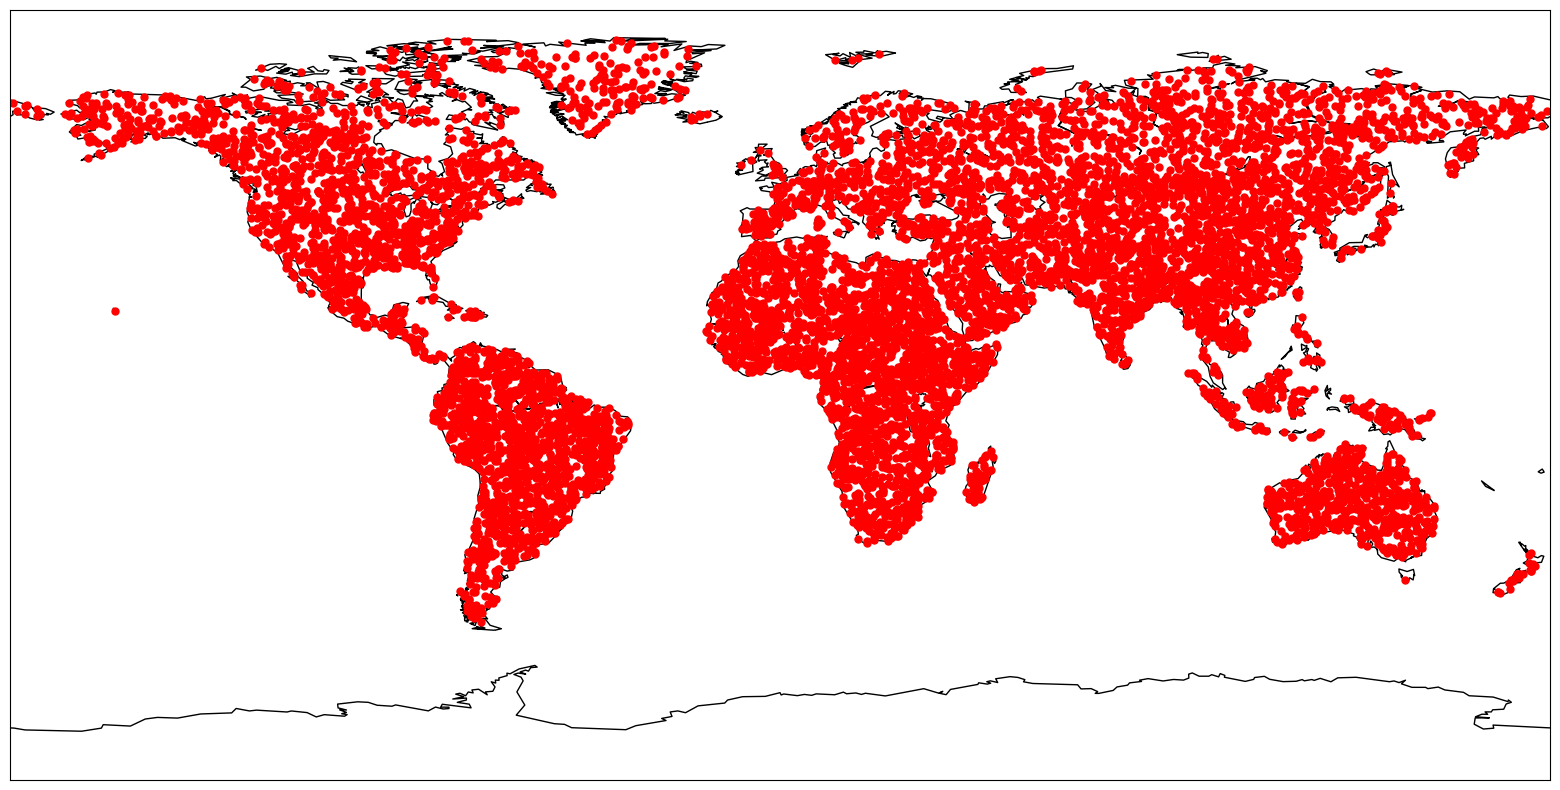

In [47]:
# Mask out land coordinates
fig, ax = plt.subplots(1,1, figsize=(20, 10))
m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()

# Plot points on map
plt.plot(land_coords[:, 0], land_coords[:, 1], 'ro', markersize=5)

In [ ]:
import pandas as pd

# Generate by year:
years = list(range(2015, 2021))
print(years)

for year in years:
    coords = sample_uniform_land_locations(200000)
    df = pd.DataFrame(coords.numpy(), columns=['longitude', 'latitude'])
    df.to_csv(f"s2_requests/locations_from_{year}-01-01_to_{year}-12-31.csv", index=False)

[2015, 2016, 2017, 2018, 2019, 2020]


/var/folders/r1/pjzkjcnx06s10y73t_xjbm280000gr/T/ipykernel_31098/2732450061.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lat = np.arcsin(xyz_coords[:, 2]) * 180 / np.pi
/var/folders/r1/pjzkjcnx06s10y73t_xjbm280000gr/T/ipykernel_31098/2732450061.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  lon = np.arctan2(xyz_coords[:, 1], xyz_coords[:, 0]) * 180 / np.pi


KeyboardInterrupt: 